# Hamilton Recession Index — Honest Benchmarking with Macro + Google Trends

**Central question:** Do macroeconomic features and Google Trends search data add predictive
information about the Hamilton GDP-based recession index **beyond what AR(2) persistence captures?**

**Four models, compared head-to-head on an 80 / 20 time-series split:**

| # | Model | Form |
|---|-------|------|
| **M1** | Naive persistence (oracle) | `ŷ[t] = y_actual[t-2]` — true value from 2 months ago. Unfair upper bound. |
| **M2** | AR(2) recursive | `ŷ[t] = α + φ₁·ŷ[t-1] + φ₂·ŷ[t-2]` — uses own prior predictions. Honest baseline. |
| **M3** | Macro + Trends logit-OLS | `logit(y/100) = α + γ'·X[t-k]` — all 11 features, no lagged target. |
| **M4** | **AR(2) + Macro + Trends** *(main test)* | Full model with AR(2) + all 11 features. Joint F-test for γ=0. |

**Features (11 total):**
- *Macro (6):* GDP growth, inflation, fed funds rate (Δ), yield spread, unemployment (Δ), PCE growth
- *Google Trends (5):* recession, unemployment, layoffs, economic crisis, inflation

All bounded predictions use the **logit transform** so predictions stay strictly in (0, 100).
Recursive forecasts never peek at true Hamilton values during the test period.

## Setup — imports, bounded-target helpers, data load


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, kpss
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
# from scipy.special import logit as _logit, expit as _expit

import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.figsize': (14, 5),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3,
    'font.size': 11,
})
HAMILTON_LO, HAMILTON_HI = 0.0, 100.0

def bounded_metrics(y_true, y_pred):
    y_pred = np.asarray(y_pred)
    return {
        'R2'   : r2_score(y_true, y_pred),
        'RMSE' : np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAE'  : mean_absolute_error(y_true, y_pred),
        'OOB%' : 100.0 * np.mean((y_pred < HAMILTON_LO) | (y_pred > HAMILTON_HI)),
    }

print('✅ Libraries')


✅ Libraries


In [2]:
# ── Load and clean data ──────────────────────────────────────────────────────
master = pd.read_csv('macro_data_interpolated_Sahm.csv', index_col=0, parse_dates=True)

macro_features = ['gdp_growth', 'inflation', 'fed_funds', 'yield_spread',
                  'unemployment', 'pce_growth']

# Data is already interpolated — do NOT ffill again (would recreate the flat-block problem)

print(f'Dataset    : {master.shape}   {master.index.min().date()} → {master.index.max().date()}')
print(f'Recessions : {int((master.recession==1).sum())} months')
print(f'Hamilton   : min={master.hamilton.min():.1f}  max={master.hamilton.max():.1f}  '
      f'#zeros={int((master.hamilton==0).sum())}  #hundreds={int((master.hamilton==100).sum())}')


def shade_recessions(ax, color='#cccccc', alpha=0.4):
    rec = master['recession'].fillna(0).astype(int)
    in_rec, start, first = False, None, True
    for d, v in rec.items():
        if v == 1 and not in_rec:
            start, in_rec = d, True
        elif v == 0 and in_rec:
            ax.axvspan(start, d, color=color, alpha=alpha,
                       label='Recession' if first else None)
            in_rec, first = False, False
    if in_rec:
        ax.axvspan(start, master.index[-1], color=color, alpha=alpha)

Dataset    : (432, 9)   1990-01-31 → 2025-12-31
Recessions : 36 months
Hamilton   : min=-0.4  max=9.5  #zeros=56  #hundreds=0


## EDA


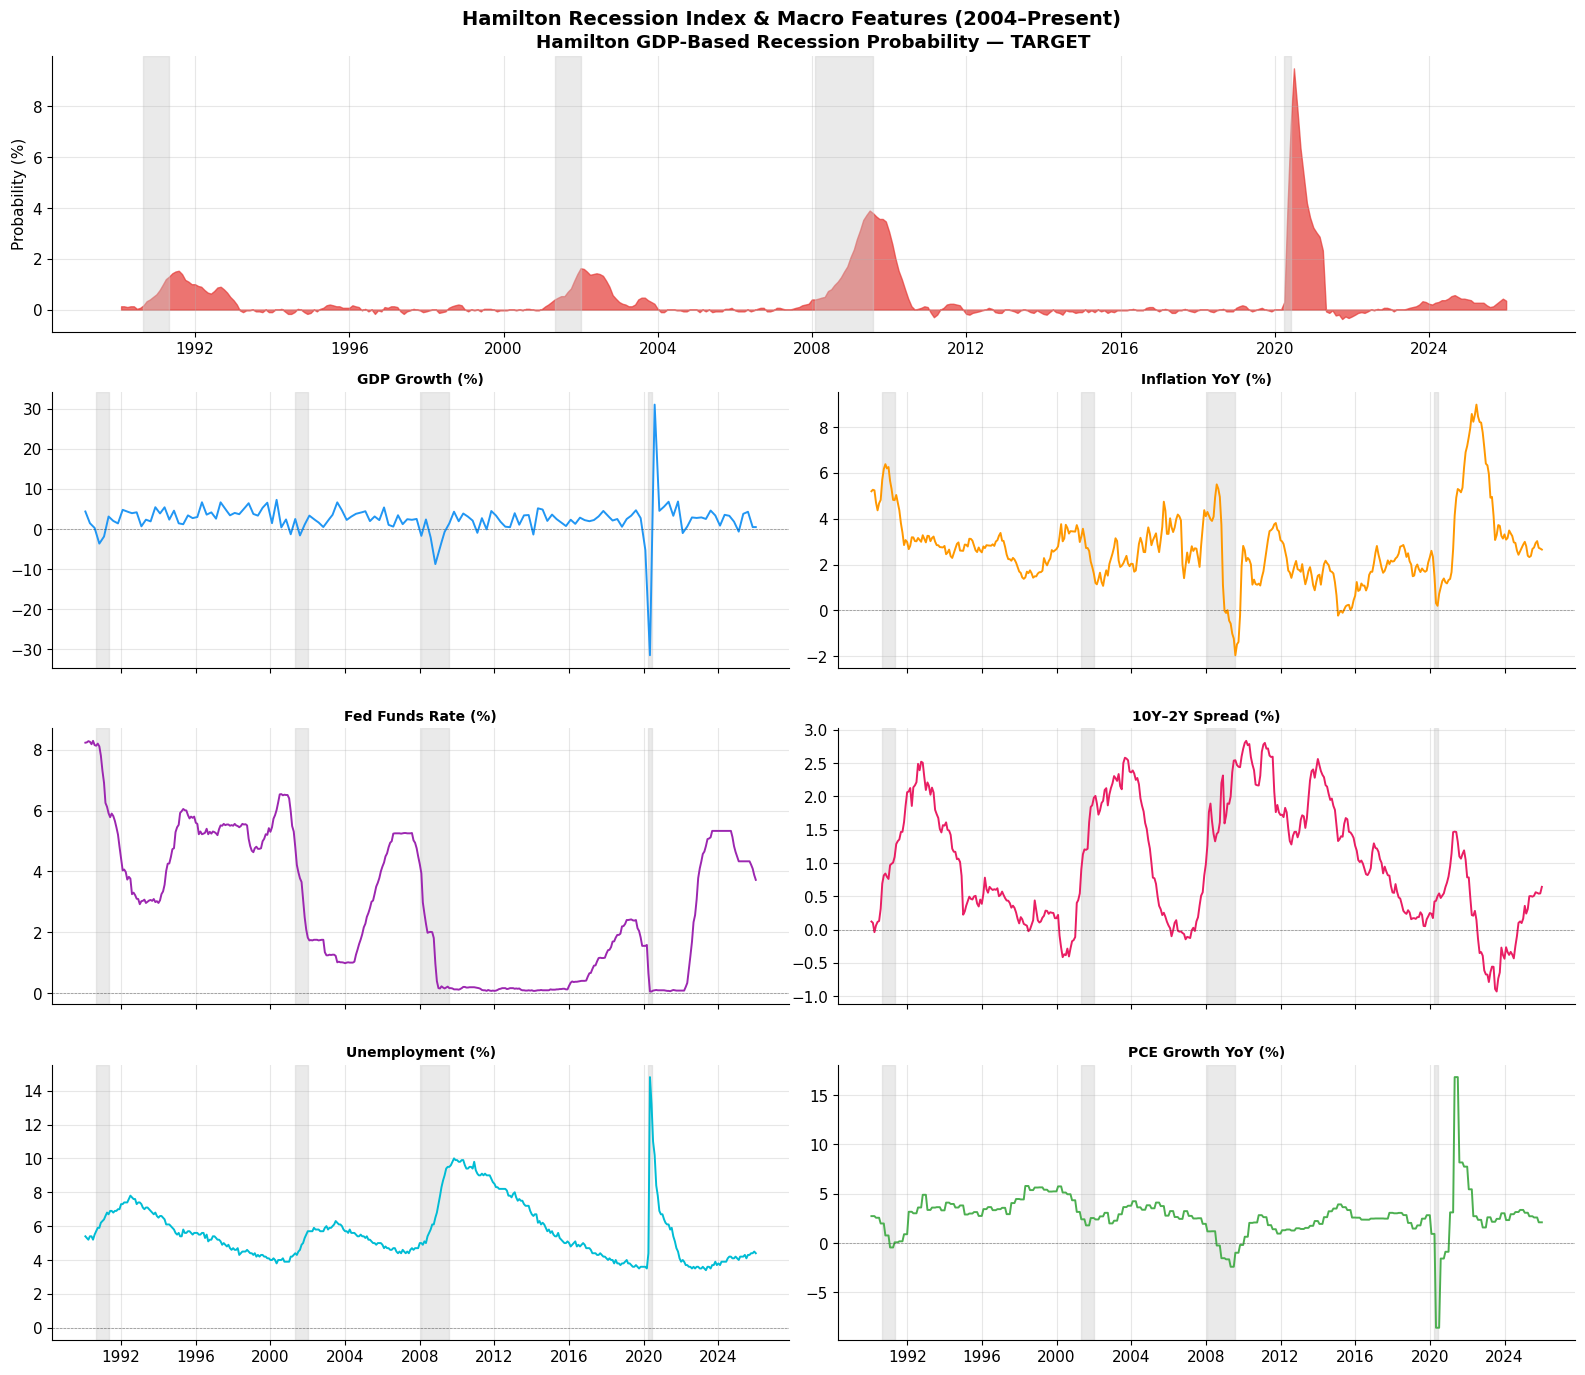

In [3]:
# ── EDA: Hamilton Index + Macro features ─────────────────────────────────────
fig, axes = plt.subplots(4, 2, figsize=(16, 14), sharex=True)
fig.suptitle('Hamilton Recession Index & Macro Features (2004–Present)',
             fontsize=14, fontweight='bold')

axes[0, 0].remove(); axes[0, 1].remove()
ax_top = fig.add_subplot(4, 1, 1)
ax_top.fill_between(master.index, master['hamilton'], color='#E53935', alpha=0.7)
shade_recessions(ax_top)
ax_top.set_title('Hamilton GDP-Based Recession Probability — TARGET', fontweight='bold')
ax_top.set_ylabel('Probability (%)')

plots = [
    ('gdp_growth',   'GDP Growth (%)',       '#2196F3'),
    ('inflation',    'Inflation YoY (%)',    '#FF9800'),
    ('fed_funds',    'Fed Funds Rate (%)',   '#9C27B0'),
    ('yield_spread', '10Y–2Y Spread (%)',    '#E91E63'),
    ('unemployment', 'Unemployment (%)',     '#00BCD4'),
    ('pce_growth',   'PCE Growth YoY (%)',   '#4CAF50'),
]
feat_axes = [axes[1,0], axes[1,1], axes[2,0], axes[2,1], axes[3,0], axes[3,1]]
for ax, (feat, label, color) in zip(feat_axes, plots):
    ax.plot(master.index, master[feat], color=color, linewidth=1.4)
    ax.axhline(0, color='black', linewidth=0.5, linestyle='--', alpha=0.4)
    shade_recessions(ax)
    ax.set_title(label, fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# # ── EDA: Google Trends features ───────────────────────────────────────────────
# fig, axes = plt.subplots(3, 2, figsize=(16, 10), sharex=True)
# fig.suptitle('Google Trends Features (2004–Present)', fontsize=14, fontweight='bold')

# trend_plots = [
#     ('trend_recession',        'Search: "recession"',        '#E53935'),
#     ('trend_unemployment',     'Search: "unemployment"',     '#1976D2'),
#     ('trend_layoffs',          'Search: "layoffs"',          '#F57C00'),
#     ('trend_economic_crisis',  'Search: "economic crisis"',  '#7B1FA2'),
#     ('trend_inflation',        'Search: "inflation"',        '#00838F'),
# ]
# for idx, (feat, label, color) in enumerate(trend_plots):
#     ax = axes[idx // 2, idx % 2]
#     ax.plot(master.index, master[feat], color=color, linewidth=1.4)
#     shade_recessions(ax)
#     ax.set_title(label, fontsize=10, fontweight='bold')
# axes[2, 1].set_visible(False)

# plt.tight_layout()
# plt.show()

## Step 1 — Stationarity: ADF + KPSS

Macro features and the target are tested. Non-stationary macro features are replaced with
first differences. **Google Trends features are excluded from differencing** — they are
already expressed as relative search rates and are treated as stationary by design.

- ADF (H₀ = non-stationary): reject (p < 0.05) ⇒ stationary.
- KPSS (H₀ = stationary): fail to reject (p > 0.05) ⇒ stationary.
- "Stationary" verdict requires both tests agree.

In [4]:
def stationarity_tests(series, name):
    s = series.dropna()
    adf_p  = adfuller(s, autolag='AIC')[1]
    kpss_p = kpss(s, regression='c', nlags='auto')[1]
    return {
        'series': name,
        'ADF p':  round(adf_p,  4),  'ADF ok':  '✅' if adf_p  < 0.05 else '❌',
        'KPSS p': round(kpss_p, 4),  'KPSS ok': '✅' if kpss_p > 0.05 else '❌',
        'stationary': (adf_p < 0.05) and (kpss_p > 0.05),
    }

rows = [stationarity_tests(master[c], c) for c in macro_features + ['hamilton']]

stat_df = pd.DataFrame(rows)
print('─ Stationarity verdicts ─')
print(stat_df[['series','ADF p','ADF ok','KPSS p','KPSS ok','stationary']].to_string(index=False))

# Replace non-stationary FEATURES with first differences
nonstat = [r['series'] for r in rows
           if r['series'] in macro_features and not r['stationary']]

df_work = master[macro_features + ['hamilton']].copy()
for feat in nonstat:
    d = df_work[feat].diff()
    ok = stationarity_tests(d, f'd({feat})')['stationary']
    if ok:
        df_work[feat] = d
        print(f'  Replaced {feat} with first difference.')
    else:
        print(f'  ⚠️  d({feat}) still non-stationary.')
df_work = df_work.dropna()
print(f'Working df  : {df_work.shape}   {df_work.index.min().date()} → {df_work.index.max().date()}')

─ Stationarity verdicts ─
      series  ADF p ADF ok  KPSS p KPSS ok  stationary
  gdp_growth 0.0010      ✅    0.10       ✅        True
   inflation 0.0032      ✅    0.10       ✅        True
   fed_funds 0.0116      ✅    0.01       ❌       False
yield_spread 0.0088      ✅    0.10       ✅        True
unemployment 0.0725      ❌    0.10       ✅       False
  pce_growth 0.0041      ✅    0.10       ✅        True
    hamilton 0.0002      ✅    0.10       ✅        True
  Replaced fed_funds with first difference.
  Replaced unemployment with first difference.
Working df  : (431, 7)   1990-02-28 → 2025-12-31


## Step 3 — Train/test split (80 / 20)

Features shifted by their custom lags. Target pre-computed in logit space:

- `hamilton`   — level (0–100)
- `y_z`        — `logit(hamilton/100)`, used by all models
- `y_z_lag`    — `y_z.shift(1)`, AR lag-1 term (φ₁)
- `y_z_lag2`   — `y_z.shift(2)`, AR lag-2 term (φ₂)

In [5]:
df_custom = df_work[macro_features + ['hamilton']].copy()
# for feat, lag in custom_lags.items():
#     df_custom[feat] = df_custom[feat].shift(lag)
df_custom[macro_features] = df_custom[macro_features].shift(1)
df_custom = df_custom.dropna()

df_custom['h_lag']  = df_custom['hamilton'].shift(1)
df_custom['h_lag2'] = df_custom['hamilton'].shift(2)
df_custom = df_custom.dropna()

split = int(len(df_custom) * 0.80)
train, test = df_custom.iloc[:split], df_custom.iloc[split:]

y_tr = train['hamilton']; y_te = test['hamilton']

print(f'Train: {train.index.min().date()} → {train.index.max().date()}  ({len(train)} obs)')
print(f'Test : {test.index.min().date()}  → {test.index.max().date()}  ({len(test)} obs)')


Train: 1990-05-31 → 2018-10-31  (342 obs)
Test : 2018-11-30  → 2025-12-31  (86 obs)


#### ACF and PACF for Recession Index

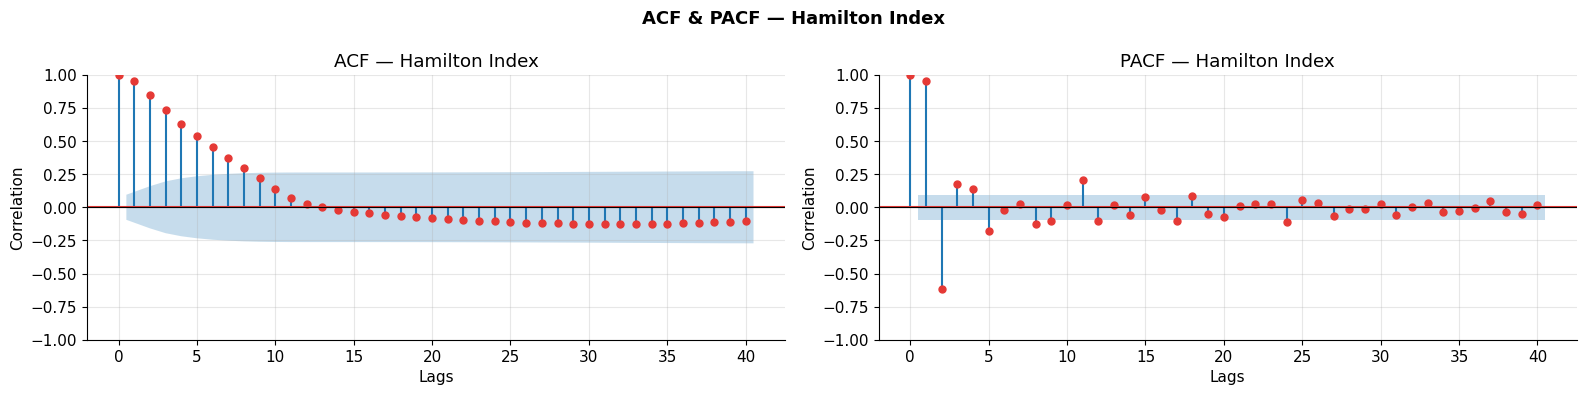

─── ACF values (first 12 lags) ───
 Lag  ACF Hamilton
   0        1.0000
   1        0.9525
   2        0.8498
   3        0.7310
   4        0.6256
   5        0.5347
   6        0.4526
   7        0.3756
   8        0.2995
   9        0.2200
  10        0.1385
  11        0.0722
  12        0.0267


In [6]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(16, 4))
fig.suptitle('ACF & PACF — Hamilton Index', fontweight='bold', fontsize=13)

plot_acf(df_custom['hamilton'].dropna(), lags=40, ax=axes[0],
         title='ACF — Hamilton Index', color='#E53935', alpha=0.05)
plot_pacf(df_custom['hamilton'].dropna(), lags=40, ax=axes[1],
          title='PACF — Hamilton Index', color='#E53935', alpha=0.05, method='ywm')

for ax in axes.flat:
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Lags')
    ax.set_ylabel('Correlation')

plt.tight_layout()
plt.show()

# ── Numerical summary of first 12 lags ───────────────────────────────────────
from statsmodels.tsa.stattools import acf, pacf

acf_orig = acf(df_custom['hamilton'].dropna(), nlags=12, fft=True)

print('─── ACF values (first 12 lags) ───')
print(pd.DataFrame({
    'Lag'         : range(13),
    'ACF Hamilton': acf_orig.round(4),
}).to_string(index=False))

## Step 4 — Benchmarks: AR(2) persistence models

**M1 — Naive persistence (oracle).** `ŷ[t] = y_actual[t-2]`. Uses the true Hamilton value
from 2 months ago at every test step. This is an unfair upper bound — it never compounds errors.

**M2 — AR(2) recursive (honest baseline).** Fits φ₁ and φ₂ on training data, then rolls forward
using its **own prior predictions** as inputs — no access to true Hamilton values during the test period.
Errors compound over the 84-month horizon, which is why recursive R² collapses far below the oracle.

In [7]:
# ── M1: naive persistence with oracle (lag 2) ─────────────────────────────────
y_prev_oracle = pd.concat([y_tr.iloc[[-2, -1]], y_te]).shift(2).dropna()
m1_te = bounded_metrics(y_te, y_prev_oracle.values)

X_ar_tr = sm.add_constant(train[['h_lag', 'h_lag2']])
ar_model = sm.OLS(train['hamilton'], X_ar_tr).fit()

y_hat_m2_tr = ar_model.predict(X_ar_tr)
m2_tr = bounded_metrics(y_tr, y_hat_m2_tr)

z_prev1 = train['hamilton'].iloc[-1]
z_prev2 = train['hamilton'].iloc[-2]

z_hats = []
for _ in range(len(test)):
    z_t = (ar_model.params['const']
           + ar_model.params['h_lag']  * z_prev1
           + ar_model.params['h_lag2'] * z_prev2)
    z_hats.append(z_t)
    z_prev2 = z_prev1   # shift: t-1 becomes t-2
    z_prev1 = z_t       # recursive: own prediction becomes new t-1

y_hat_m2 = pd.Series(np.array(z_hats), index=test.index)
m2_te = bounded_metrics(y_te, y_hat_m2.values)

# Contrast: AR(2) ONE-STEP-AHEAD with actual y[t-1], y[t-2] each step (oracle)
z_oracle = (ar_model.params['const']
            + ar_model.params['h_lag']  * test['h_lag'].values
            + ar_model.params['h_lag2'] * test['h_lag2'].values)
y_hat_m2_oracle = pd.Series(z_oracle, index=test.index)
m2_oracle = bounded_metrics(y_te, y_hat_m2_oracle.values)

print('── Benchmarks: persistence only (no macro features) ──')
print(f'{"Model":<44} {"R²_train":>9} {"R²_test":>9} {"RMSE_test":>10}')
print('-' * 76)
print(f'{"M1 if t-2 value is the current value":<44} '
      f'{"—":>9} {m1_te["R2"]:>9.4f} {m1_te["RMSE"]:>10.3f}')
print(f'{"M2  AR(2) Taking Actual Previous Values":<44} '
      f'{m2_tr["R2"]:>9.4f} {m2_oracle["R2"]:>9.4f} {m2_oracle["RMSE"]:>10.3f}')
print(f'{"M2  AR(2) Taking Predicted Values":<44} '
      f'{m2_tr["R2"]:>9.4f} {m2_te["R2"]:>9.4f} {m2_te["RMSE"]:>10.3f}')

── Benchmarks: persistence only (no macro features) ──
Model                                         R²_train   R²_test  RMSE_test
----------------------------------------------------------------------------
M1 if t-2 value is the current value                 —    0.5530      1.264
M2  AR(2) Taking Actual Previous Values         0.9855    0.9081      0.573
M2  AR(2) Taking Predicted Values               0.9855   -0.0899      1.973


## Step 5 — M3: Macro + Trends logit-OLS

All 11 features (6 macro + 5 trends), no lagged target. Custom leading lags from Step 2.
Bounded via logit transform.

No recursion needed: features `X[t-k]` are from k months ago — already observed at prediction time.

In [8]:
X_tr_m = sm.add_constant(train[macro_features])
X_te_m = sm.add_constant(test[macro_features]).reindex(columns=X_tr_m.columns, fill_value=1)

macro_model = sm.OLS(train['hamilton'], X_tr_m).fit()

y_hat_m3_tr = macro_model.predict(X_tr_m)
y_hat_m3_te = macro_model.predict(X_te_m)
m3_tr = bounded_metrics(y_tr, y_hat_m3_tr)
m3_te = bounded_metrics(y_te, y_hat_m3_te)

print('── M3: Macro + Trends Logit-OLS ──')
print(macro_model.summary())
print(f'\nTrain R² : {m3_tr["R2"]:>7.4f}   RMSE : {m3_tr["RMSE"]:>6.3f}   OOB% : {m3_tr["OOB%"]:>5.2f}')
print(f'Test  R² : {m3_te["R2"]:>7.4f}   RMSE : {m3_te["RMSE"]:>6.3f}   OOB% : {m3_te["OOB%"]:>5.2f}')

── M3: Macro + Trends Logit-OLS ──
                            OLS Regression Results                            
Dep. Variable:               hamilton   R-squared:                       0.560
Model:                            OLS   Adj. R-squared:                  0.552
Method:                 Least Squares   F-statistic:                     71.14
Date:                Wed, 29 Apr 2026   Prob (F-statistic):           7.74e-57
Time:                        13:16:17   Log-Likelihood:                -244.24
No. Observations:                 342   AIC:                             502.5
Df Residuals:                     335   BIC:                             529.3
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const        

## Step 6 — M4: Augmented AR(2) + Macro + Trends — MAIN TEST

**Full model:**
$$\text{logit}(y_t / 100) = \alpha + \varphi_1\,\text{logit}(y_{t-1}/100) + \varphi_2\,\text{logit}(y_{t-2}/100) + \gamma' X_{t-k} + \varepsilon_t$$

where $X_{t-k}$ includes all 11 features (6 macro + 5 trends).

**Joint F-test:** H₀ : γ₁ = ⋯ = γ₁₁ = 0.
Rejecting H₀ means features add explanatory power **beyond AR(2) persistence alone.**

Out-of-sample: **recursive forecast** — both AR terms use the model's own prior predictions.

In [9]:
# Full model: AR(2) lags + macro + trend features
X_full_tr = sm.add_constant(train[['h_lag', 'h_lag2'] + macro_features])
X_full_te = sm.add_constant(test [['h_lag', 'h_lag2'] + macro_features]).reindex(
    columns=X_full_tr.columns, fill_value=1)

full_model = sm.OLS(train['hamilton'], X_full_tr).fit()

# ── JOINT F-TEST: do features add info beyond AR(2)? ─────────────────────────
constraints = ', '.join([f'{f}=0' for f in macro_features])
f_result    = full_model.f_test(constraints)
f_stat      = float(f_result.fvalue)
f_pvalue    = float(f_result.pvalue)
f_df        = (int(f_result.df_num), int(f_result.df_denom))

print('── JOINT F-TEST  H₀: features add nothing beyond AR(2) ──')
print(f'  F-statistic : {f_stat:.4f}')
print(f'  p-value     : {f_pvalue:.4e}')
print(f'  df          : {f_df}')
verdict = ('REJECT H₀ — features add information beyond AR(2).'
           if f_pvalue < 0.05 else
           'FAIL TO REJECT H₀ — features add nothing beyond AR(2).')
print(f'  Verdict (α=0.05): {verdict}')

print(f'\nIn-sample R²:')
print(f'  M2 restricted (AR(2) only) : {ar_model.rsquared:.4f}')
print(f'  M4 full (AR(2) + macros)   : {full_model.rsquared:.4f}')
print(f'  Incremental R²                      : {full_model.rsquared - ar_model.rsquared:+.4f}')

# ── In-sample fitted values ───────────────────────────────────────────────────
y_hat_m4_tr = full_model.predict(X_full_tr)
m4_tr = bounded_metrics(y_tr, y_hat_m4_tr)

# ── OOS RECURSIVE forecast — AR(2): both lags use own prior predictions ───────
z_prev1 = train['hamilton'].iloc[-1]
z_prev2 = train['hamilton'].iloc[-2]

z_hats = []
for _, row in test.iterrows():
    z_t = (full_model.params['const']
           + full_model.params['h_lag']  * z_prev1
           + full_model.params['h_lag2'] * z_prev2)
    for f in macro_features:
        z_t += full_model.params[f] * row[f]
    z_hats.append(z_t)
    z_prev2 = z_prev1
    z_prev1 = z_t

y_hat_m4 = pd.Series(np.array(z_hats), index=test.index)
m4_te = bounded_metrics(y_te, y_hat_m4.values)

# ── ORACLE one-step-ahead (reference only) ───────────────────────────────────
z_oracle = full_model.predict(X_full_te)
y_hat_m4_oracle = z_oracle
m4_oracle = bounded_metrics(y_te, y_hat_m4_oracle)

print('\n' + '=' * 70)
print('M4 FULL OLS SUMMARY')
print('=' * 70)
print(full_model.summary())

print(f'\n── M4 Evaluation on 0–100 scale ──')
print(f'  Train R² (in-sample, fitted)              : {m4_tr["R2"]:>7.4f}   RMSE: {m4_tr["RMSE"]:>6.3f}')
print(f'  Test  R² (oracle — true prior values)     : {m4_oracle["R2"]:>7.4f}   RMSE: {m4_oracle["RMSE"]:>6.3f}')
print(f'  Test  R² (recursive — honest, no peeking) : {m4_te["R2"]:>7.4f}   RMSE: {m4_te["RMSE"]:>6.3f}')

── JOINT F-TEST  H₀: features add nothing beyond AR(2) ──
  F-statistic : 7.0400
  p-value     : 4.5470e-07
  df          : (6, 333)
  Verdict (α=0.05): REJECT H₀ — features add information beyond AR(2).

In-sample R²:
  M2 restricted (AR(2) only) : 0.9855
  M4 full (AR(2) + macros)   : 0.9872
  Incremental R²                      : +0.0016

M4 FULL OLS SUMMARY
                            OLS Regression Results                            
Dep. Variable:               hamilton   R-squared:                       0.987
Model:                            OLS   Adj. R-squared:                  0.987
Method:                 Least Squares   F-statistic:                     3201.
Date:                Wed, 29 Apr 2026   Prob (F-statistic):          8.62e-310
Time:                        13:16:17   Log-Likelihood:                 360.07
No. Observations:                 342   AIC:                            -702.1
Df Residuals:                     333   BIC:                            -667.6
Df M

## Step 7 — Summary & final verdict

All four models side-by-side on the same 80/20 split, with **honest** out-of-sample metrics.
The bottom line is **M4 (AR(2) + macro + trends) vs. M2 (AR(2) recursive)**:
- Does the F-test reject γ = 0? (Do features add in-sample information beyond persistence?)
- Does M4's honest recursive R² beat M2's? (Does the signal generalise out-of-sample?)

MODEL COMPARISON  (test metrics on 0–100 scale)
                                           Model  R²_train  R²_test  RMSE_test  MAE_test
   M1  Naive persistence (lag-2 oracle — unfair)       NaN   0.5530     1.2638    0.4772
M2  AR(2) oracle (true prior values — reference)    0.9855   0.9081     0.5731    0.2007
           M2  AR(2) recursive (honest baseline)    0.9855  -0.0899     1.9734    0.8371
                              M3  Macro-only OLS    0.5603  -0.1237     2.0038    1.0989
            M4  AR(2) + Macro oracle (reference)    0.9872   0.9220     0.5279    0.1914
            M4  AR(2) + Macro recursive (honest)    0.9872   0.4877     1.3530    0.8252

Oracle rows: true Hamilton values used as AR inputs — reference only, not deployable.
Recursive rows: own prior predictions fed back — the only honest evaluation.


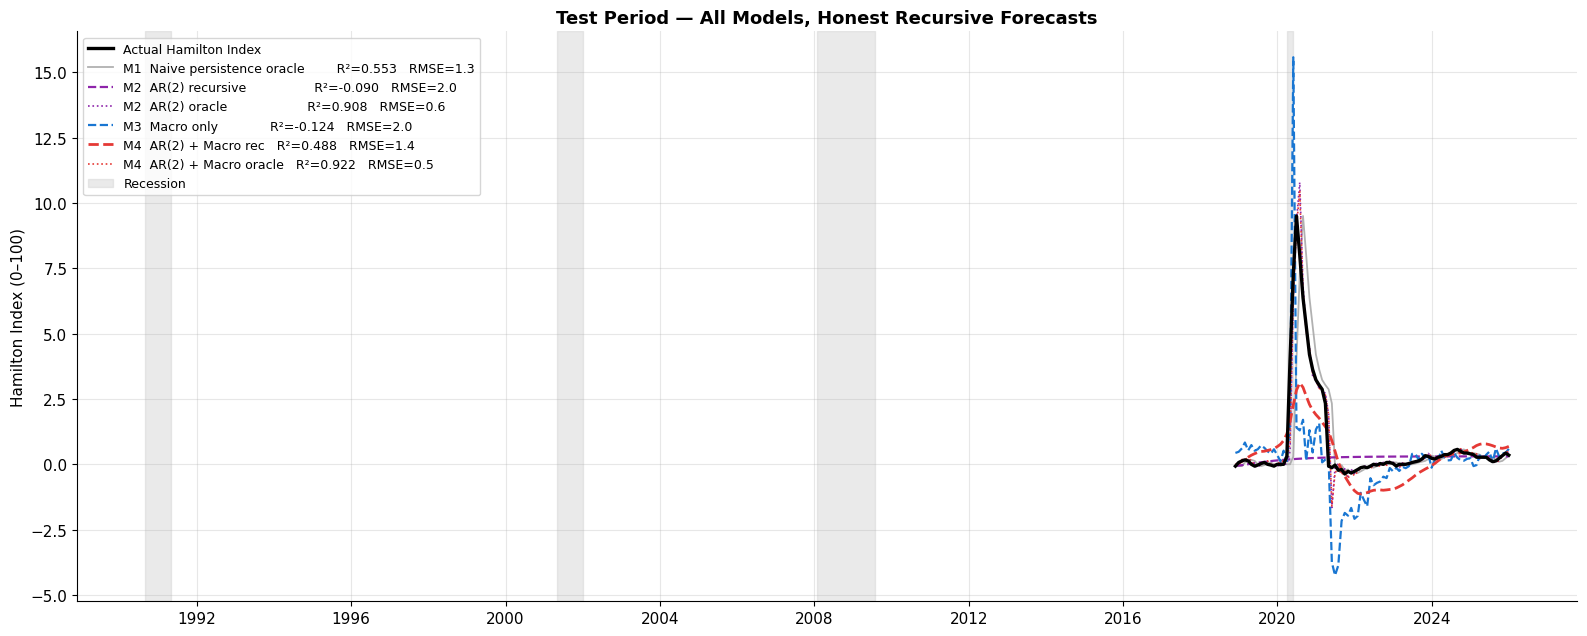


FINAL VERDICT — Do macro + trend features add info beyond AR(2) persistence?
  (1) In-sample F-test (features | AR(2)) : F=7.040   p=4.5470e-07   df=(6, 333)
  (2) Incremental in-sample R²          : +0.0016
  (3) Out-of-sample RECURSIVE R²:
        M2 AR(2) alone               : -0.0899   RMSE=2.0
        M4 AR(2) + macro + trends    : +0.4877   RMSE=1.4
        Δ (M4 − M2)                  : +0.5776

  ✅  Features add BOTH statistically significant in-sample information AND out-of-sample predictive value over AR(2).


In [10]:
# ── Comparison table ────────────────────────────────────────────────────────
summary = pd.DataFrame([
    {'Model': 'M1  Naive persistence (lag-2 oracle — unfair)',
     'R²_train': np.nan, 'R²_test': m1_te['R2'],
     'RMSE_test': m1_te['RMSE'], 'MAE_test': m1_te['MAE']},
    {'Model': 'M2  AR(2) oracle (true prior values — reference)',
     'R²_train': m2_tr['R2'], 'R²_test': m2_oracle['R2'],
     'RMSE_test': m2_oracle['RMSE'], 'MAE_test': m2_oracle['MAE']},
    {'Model': 'M2  AR(2) recursive (honest baseline)',
     'R²_train': m2_tr['R2'], 'R²_test': m2_te['R2'],
     'RMSE_test': m2_te['RMSE'], 'MAE_test': m2_te['MAE']},
    {'Model': 'M3  Macro-only OLS',
     'R²_train': m3_tr['R2'], 'R²_test': m3_te['R2'],
     'RMSE_test': m3_te['RMSE'], 'MAE_test': m3_te['MAE']},
    {'Model': 'M4  AR(2) + Macro oracle (reference)',
     'R²_train': m4_tr['R2'], 'R²_test': m4_oracle['R2'],
     'RMSE_test': m4_oracle['RMSE'], 'MAE_test': m4_oracle['MAE']},
    {'Model': 'M4  AR(2) + Macro recursive (honest)',
     'R²_train': m4_tr['R2'], 'R²_test': m4_te['R2'],
     'RMSE_test': m4_te['RMSE'], 'MAE_test': m4_te['MAE']},
])

print('=' * 90)
print('MODEL COMPARISON  (test metrics on 0–100 scale)')
print('=' * 90)
print(summary.to_string(index=False, float_format=lambda v: f'{v:7.4f}'))
print()
print('Oracle rows: true Hamilton values used as AR inputs — reference only, not deployable.')
print('Recursive rows: own prior predictions fed back — the only honest evaluation.')

# ── Forecast plot ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 6.5))
ax.plot(y_te.index, y_te.values, color='black', linewidth=2.4,
        label='Actual Hamilton Index', zorder=10)
ax.plot(y_prev_oracle.index, y_prev_oracle.values, color='#9E9E9E',
        linewidth=1.3, alpha=0.8,
        label=f'M1  Naive persistence oracle        R²={m1_te["R2"]:.3f}   RMSE={m1_te["RMSE"]:.1f}')
ax.plot(y_hat_m2.index, y_hat_m2.values, color='#8E24AA',
        linewidth=1.6, linestyle='--',
        label=f'M2  AR(2) recursive                 R²={m2_te["R2"]:.3f}   RMSE={m2_te["RMSE"]:.1f}')
ax.plot(y_hat_m2_oracle.index, y_hat_m2_oracle.values, color='#8E24AA',
        linewidth=1.2, linestyle=':',
        label=f'M2  AR(2) oracle                    R²={m2_oracle["R2"]:.3f}   RMSE={m2_oracle["RMSE"]:.1f}')
ax.plot(y_hat_m3_te.index, y_hat_m3_te.values, color='#1976D2',
        linewidth=1.6, linestyle='--',
        label=f'M3  Macro only             R²={m3_te["R2"]:.3f}   RMSE={m3_te["RMSE"]:.1f}')
ax.plot(y_hat_m4.index, y_hat_m4.values, color='#E53935',
        linewidth=2.0, linestyle='--',
        label=f'M4  AR(2) + Macro rec   R²={m4_te["R2"]:.3f}   RMSE={m4_te["RMSE"]:.1f}')
ax.plot(y_hat_m4_oracle.index, y_hat_m4_oracle.values, color='#E53935',
        linewidth=1.2, linestyle=':',
        label=f'M4  AR(2) + Macro oracle   R²={m4_oracle["R2"]:.3f}   RMSE={m4_oracle["RMSE"]:.1f}')
shade_recessions(ax)
ax.set_title('Test Period — All Models, Honest Recursive Forecasts',
             fontweight='bold', fontsize=13)
ax.set_ylabel('Hamilton Index (0–100)')
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

# ── FINAL VERDICT ────────────────────────────────────────────────────────────
print('\n' + '=' * 80)
print('FINAL VERDICT — Do macro + trend features add info beyond AR(2) persistence?')
print('=' * 80)
print(f'  (1) In-sample F-test (features | AR(2)) : F={f_stat:.3f}   p={f_pvalue:.4e}   df={f_df}')
print(f'  (2) Incremental in-sample R²          : {full_model.rsquared - ar_model.rsquared:+.4f}')
print(f'  (3) Out-of-sample RECURSIVE R²:')
print(f'        M2 AR(2) alone               : {m2_te["R2"]:+.4f}   RMSE={m2_te["RMSE"]:.1f}')
print(f'        M4 AR(2) + macro + trends    : {m4_te["R2"]:+.4f}   RMSE={m4_te["RMSE"]:.1f}')
print(f'        Δ (M4 − M2)                  : {m4_te["R2"] - m2_te["R2"]:+.4f}')

if f_pvalue < 0.05 and m4_te['R2'] > m2_te['R2']:
    conclusion = ('✅  Features add BOTH statistically significant in-sample '
                  'information AND out-of-sample predictive value over AR(2).')
elif f_pvalue < 0.05:
    conclusion = ('⚠️   Features are statistically significant in-sample but DO NOT '
                  'improve out-of-sample R² — likely in-sample overfit.')
elif m4_te['R2'] > m2_te['R2']:
    conclusion = ('⚠️   Features improve out-of-sample R² but the in-sample F-test '
                  'does not reject H₀ — signal may be small/noisy.')
else:
    conclusion = ('❌  Features fail both tests: not significant in-sample and do '
                  'not improve out-of-sample over pure AR(2) persistence.')
print(f'\n  {conclusion}')